<a href="https://colab.research.google.com/github/badhayearushi-alt/-Loan-Approval-Prediction/blob/main/task_22_optional.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Import Libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# Upload Dataset
from google.colab import files

uploaded = files.upload()

Saving Loan Prediction Dataset.csv to Loan Prediction Dataset.csv


In [ ]:
# Load Dataset
df = pd.read_csv("Loan Prediction Dataset.csv")

In [ ]:
if "Loan_ID" in df.columns:
      df.drop("Loan_ID", axis=1, inplace=True)

In [ ]:
print(df.head(10))

   Gender Married  Dependents     Education Self_Employed  ApplicantIncome  \
0    Male     Yes           1      Graduate            No             5000   
1  Female      No           0      Graduate            No             3000   
2    Male     Yes           2  Not Graduate           Yes             2500   

   CoapplicantIncome  LoanAmount  Loan_Amount_Term  Credit_History  \
0                  0         120               360               1   
1               1500         100               360               1   
2                  0         180               360               0   

  Property_Area  Loan_Status  
0         Urban            1  
1     Semiurban            1  
2         Rural            0  


In [ ]:
print(df.tail())

   Gender Married  Dependents     Education Self_Employed  ApplicantIncome  \
0    Male     Yes           1      Graduate            No             5000   
1  Female      No           0      Graduate            No             3000   
2    Male     Yes           2  Not Graduate           Yes             2500   

   CoapplicantIncome  LoanAmount  Loan_Amount_Term  Credit_History  \
0                  0         120               360               1   
1               1500         100               360               1   
2                  0         180               360               0   

  Property_Area  Loan_Status  
0         Urban            1  
1     Semiurban            1  
2         Rural            0  


In [ ]:
print(df.shape)

(3, 12)


In [ ]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3 entries, 0 to 2
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   Gender             3 non-null      object
 1   Married            3 non-null      object
 2   Dependents         3 non-null      int64 
 3   Education          3 non-null      object
 4   Self_Employed      3 non-null      object
 5   ApplicantIncome    3 non-null      int64 
 6   CoapplicantIncome  3 non-null      int64 
 7   LoanAmount         3 non-null      int64 
 8   Loan_Amount_Term   3 non-null      int64 
 9   Credit_History     3 non-null      int64 
 10  Property_Area      3 non-null      object
 11  Loan_Status        3 non-null      int64 
dtypes: int64(7), object(5)
memory usage: 420.0+ bytes
None


In [ ]:
print(df.dtypes)

Gender               object
Married              object
Dependents            int64
Education            object
Self_Employed        object
ApplicantIncome       int64
CoapplicantIncome     int64
LoanAmount            int64
Loan_Amount_Term      int64
Credit_History        int64
Property_Area        object
Loan_Status           int64
dtype: object


In [ ]:
print(df.isnull().sum())

Gender               0
Married              0
Dependents           0
Education            0
Self_Employed        0
ApplicantIncome      0
CoapplicantIncome    0
LoanAmount           0
Loan_Amount_Term     0
Credit_History       0
Property_Area        0
Loan_Status          0
dtype: int64


In [ ]:
print(df.duplicated().sum())

df.drop_duplicates(inplace=True)

0


In [ ]:
print(df.describe())

       Dependents  ApplicantIncome  CoapplicantIncome  LoanAmount  \
count         3.0         3.000000           3.000000    3.000000   
mean          1.0      3500.000000         500.000000  133.333333   
std           1.0      1322.875656         866.025404   41.633320   
min           0.0      2500.000000           0.000000  100.000000   
25%           0.5      2750.000000           0.000000  110.000000   
50%           1.0      3000.000000           0.000000  120.000000   
75%           1.5      4000.000000         750.000000  150.000000   
max           2.0      5000.000000        1500.000000  180.000000   

       Loan_Amount_Term  Credit_History  Loan_Status  
count               3.0        3.000000     3.000000  
mean              360.0        0.666667     0.666667  
std                 0.0        0.577350     0.577350  
min               360.0        0.000000     0.000000  
25%               360.0        0.500000     0.500000  
50%               360.0        1.000000     1.00

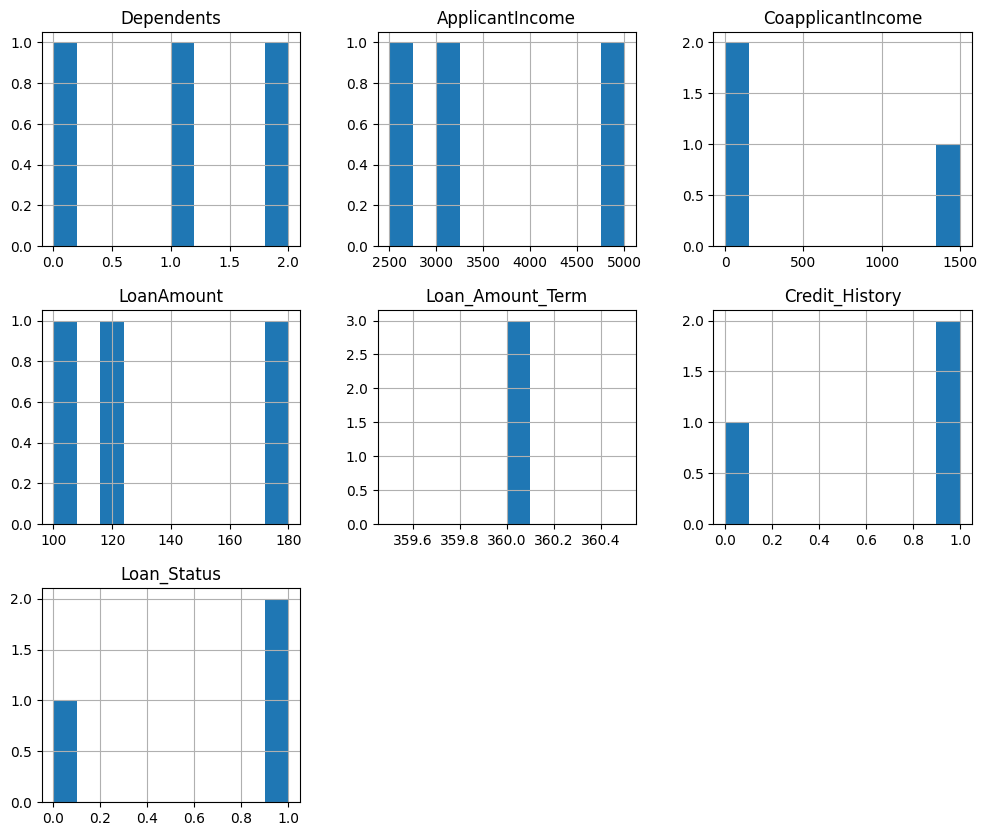

In [ ]:
import matplotlib.pyplot as plt

df.hist(figsize=(12,10))
plt.show()

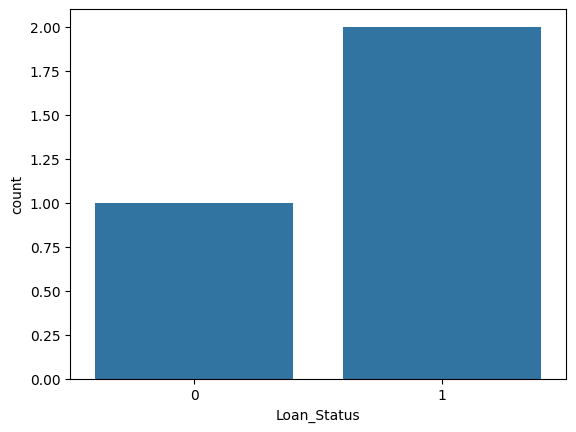

In [ ]:
import seaborn as sns

sns.countplot(x="Loan_Status", data=df)
plt.show()

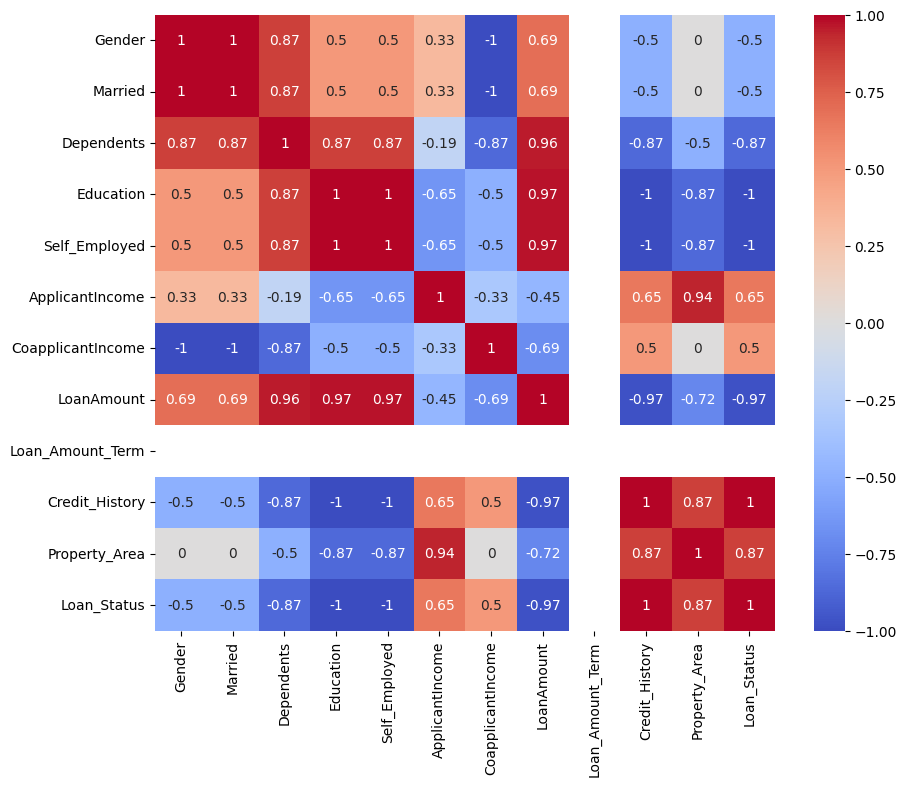

In [ ]:
temp = df.copy()

for col in temp.select_dtypes(include="object").columns:
    temp[col] = temp[col].astype("category").cat.codes

plt.figure(figsize=(10,8))
sns.heatmap(temp.corr(), annot=True, cmap="coolwarm")
plt.show()

In [ ]:
X = df.drop("Loan_Status", axis=1)
y = df["Loan_Status"]

X = pd.get_dummies(X, drop_first=True)

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X = scaler.fit_transform(X)

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
        y,
            test_size=0.2,
                random_state=42
                )

In [ ]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)

model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [ ]:
y_pred = model.predict(X_test)

print(y_pred)

[1]


In [ ]:
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

print("Accuracy :", accuracy_score(y_test, y_pred))

print(confusion_matrix(y_test, y_pred))

print(classification_report(y_test, y_pred))

Accuracy : 1.0
[[1]]
              precision    recall  f1-score   support

           1       1.00      1.00      1.00         1

    accuracy                           1.00         1
   macro avg       1.00      1.00      1.00         1
weighted avg       1.00      1.00      1.00         1



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:407: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(


In [ ]:
import joblib

joblib.dump(model, "loan_model.pkl")

print("Model Saved Successfully")

Model Saved Successfully
